# M5 -- Conformal Prediction (MAPIE)

**M9 UPDATE (2026-08-03):** re-executed against the M9 no-enrollment champion (registry v16)
after `enrollment_count` was found to be target leakage and dropped (see `decisions.md`
M9-1). Coverage moved slightly (94.6% -> 93.5%) but the mechanism, discipline, and DoD gate
below are unchanged.

Loads the calibrated XGBoost pipeline from the MLflow registry (`trialoutcome_xgb_calibrated`, stage `Production`), fits `core.conformal.MAPIEConformalWrapper` on the CALIB split, and verifies empirical coverage on TEST. CALIB is used to fit the conformal quantile; TEST is held out purely for the coverage check -- same discipline as M3's calibrator (fit on CALIB, report ECE on TEST).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

_REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

from core.conformal import MAPIEConformalWrapper
from core.dataset_builder_base import SplitDates
from domains.pharma.dataset_builder import PharmaDatasetBuilder
from domains.pharma.train_pipeline import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    REPO_ROOT,
    _apply_condition_one_hot,
    _fit_condition_vocab,
)

pd.set_option("display.width", 120)
REGISTERED_MODEL_NAME = "trialoutcome_xgb_calibrated"

/Users/shubhamagrawal/Documents/MS_fall_25/MS_fall_25_uni/ds_projects/trialoutcome/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mlflow.set_tracking_uri(f"file:{REPO_ROOT / 'mlruns'}")

calibrated_model = mlflow.sklearn.load_model(f"models:/{REGISTERED_MODEL_NAME}/Production")
print(type(calibrated_model))

<class 'sklearn.calibration.CalibratedClassifierCV'>


In [3]:
# Rebuild the identical temporal split + condition one-hot vocabulary used to
# train the Production model (register_model.py's procedure, itself identical
# to M2/M3/M4's). Deterministic given the same cached raw data + train-only
# vocabulary fit, so this reproduces the exact feature space the Production
# model expects without needing to re-derive it from the model artifact.
builder = PharmaDatasetBuilder()
raw = builder.fetch_raw()
feat = builder.build_features(raw)

split_cfg = builder.config["split"]
dates = SplitDates(
    train_end=pd.Timestamp(split_cfg["train_end"]), calib_end=pd.Timestamp(split_cfg["calib_end"])
)
temporal = builder.temporal_split(feat, date_col="start_date", split_dates=dates)

top_conditions = _fit_condition_vocab(temporal[temporal["split"] == "train"])
temporal, condition_cols = _apply_condition_one_hot(temporal, top_conditions)
feature_cols = CATEGORICAL_FEATURES + NUMERIC_FEATURES + condition_cols

calib = temporal[temporal["split"] == "calib"]
test = temporal[temporal["split"] == "test"]
X_calib, y_calib = calib[feature_cols], calib["label"]
X_test, y_test = test[feature_cols], test["label"]
print(f"calib={len(calib)}  test={len(test)}")

[build_features] 78115 rows after filters. Null rates:
  enrollment_count: 0.0157
  num_primary_outcomes: 0.0350
  num_sites: 0.0843
  allocation: 0.0220
  masking: 0.0232
  has_dmc: 0.2077
  eligibility_criteria: 0.0002
  condition_name: 0.0000
  sponsor_class: 0.0000
  sponsor_prior_termination_rate: 0.0000


calib=6310  test=5700


In [4]:
# target_coverage from domains/pharma/cost_matrix.yaml (0.90) -- the only
# pharma-specific number in this notebook; core/conformal.py itself is
# domain-agnostic.
import yaml

cost_matrix = yaml.safe_load((REPO_ROOT / "domains/pharma/cost_matrix.yaml").read_text())
target_coverage = cost_matrix["target_coverage"]
print(f"target_coverage={target_coverage}")

conformal_wrapper = MAPIEConformalWrapper(target_coverage=target_coverage)
conformal_wrapper.fit_conformal(calibrated_model, X_calib, y_calib)
print("Conformal quantile fit on CALIB split.")

target_coverage=0.9
Conformal quantile fit on CALIB split.


In [5]:
coverage_result = conformal_wrapper.verify_coverage(X_test, y_test)
coverage_result

Conformal coverage: 0.935 (target 0.90)


{'target': 0.9, 'empirical': 0.9347368421052632, 'passed': True}

## M5 conformal DoD gate

`verify_coverage`'s `passed` flag must be `True` (empirical >= 0.88) before Part B (FastAPI) proceeds. If this fails, stop here and report -- do not paper over it by relaxing the tolerance.

In [6]:
assert coverage_result["passed"], (
    f"Conformal coverage gate FAILED: empirical={coverage_result['empirical']:.3f} < 0.88 "
    "-- do not proceed to Part B (FastAPI) until this is resolved."
)
print("Conformal coverage gate PASSED -- proceeding to Part B.")

Conformal coverage gate PASSED -- proceeding to Part B.


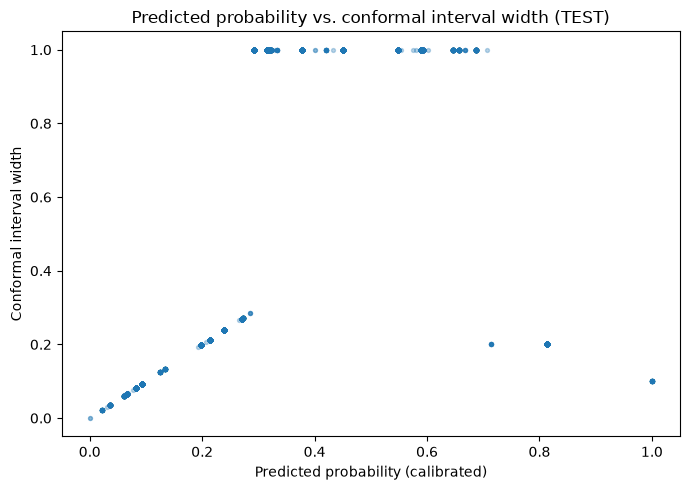

In [7]:
proba_test, intervals_test = conformal_wrapper.predict_with_interval(X_test)
widths = np.array([high - low for low, high in intervals_test])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(proba_test, widths, s=8, alpha=0.3)
ax.set_xlabel("Predicted probability (calibrated)")
ax.set_ylabel("Conformal interval width")
ax.set_title("Predicted probability vs. conformal interval width (TEST)")
fig.tight_layout()
fig.savefig(REPO_ROOT / "docs" / "conformal_width_vs_proba.png")
plt.show()

In [8]:
# 5 example predictions: proba + interval + whether the true label fell inside
# the underlying MAPIE prediction SET (the actual conformal guarantee is about
# set membership, not the derived [low, high] float band -- report both).
rng = np.random.default_rng(42)
example_idx = rng.choice(len(test), size=5, replace=False)

_, pred_sets = conformal_wrapper.mapie_.predict_set(X_test)
sets = pred_sets[:, :, 0]
y_test_arr = y_test.to_numpy()

for i in example_idx:
    p, (low, high) = proba_test[i], intervals_test[i]
    true_label = int(y_test_arr[i])
    in_set = bool(sets[i, true_label])
    print(
        f"nct_row={i:5d}  proba={p:.3f}  interval=[{low:.3f}, {high:.3f}]  "
        f"true_label={true_label}  true_label_in_set={in_set}"
    )

nct_row= 4409  proba=0.451  interval=[0.000, 1.000]  true_label=1  true_label_in_set=True
nct_row= 2501  proba=0.239  interval=[0.000, 0.239]  true_label=0  true_label_in_set=True
nct_row= 3729  proba=0.067  interval=[0.000, 0.067]  true_label=0  true_label_in_set=True
nct_row=  508  proba=0.688  interval=[0.000, 1.000]  true_label=1  true_label_in_set=True
nct_row= 2468  proba=0.377  interval=[0.000, 1.000]  true_label=0  true_label_in_set=True


In [9]:
# Log the fitted conformal wrapper + empirical coverage onto the SAME
# production run register_model.py created, so one MLflow run holds the full
# calibrated+conformal artifact set.
client = mlflow.tracking.MlflowClient()
latest = client.get_latest_versions(REGISTERED_MODEL_NAME, stages=["Production"])[0]
production_run_id = latest.run_id
print(f"Production run_id: {production_run_id}")

with mlflow.start_run(run_id=production_run_id):
    mlflow.log_metric("empirical_coverage", coverage_result["empirical"])
    mlflow.sklearn.log_model(conformal_wrapper, artifact_path="conformal")
print("Logged empirical_coverage metric and conformal/ artifact onto the production run.")

/var/folders/9p/wrdd2lcs19z3jr8v8b4c51p80000gn/T/ipykernel_74001/1361734490.py:5: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest = client.get_latest_versions(REGISTERED_MODEL_NAME, stages=["Production"])[0]
2026/08/03 00:49:31 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Production run_id: dd780d2e05974c138a18eee57b055a8d


2026/08/03 00:49:34 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/08/03 00:49:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Logged empirical_coverage metric and conformal/ artifact onto the production run.
